change `the_notebook.ipynb` name with the corresponding file name in the `href` in the next cell:

<a href="https://jupyterhub.user.eopf.eodc.eu/hub/user-redirect/git-pull?repo=https://github.com/eopf-toolkit/eopf-101&branch=main&urlpath=lab/tree/eopf-101/the_notebook.ipynb" target="_blank">
  <button style="background-color:#0072ce; color:white; padding:0.6em 1.2em; font-size:1rem; border:none; border-radius:6px; margin-top:1em;">
    🚀 Launch this notebook in JupyterLab
  </button>
</a>

### Introduction

In this notebook, we investigate the link between Land Surface Temperature (LST) and Normalised Difference Vegetation Index (NDVI) for Brussels, the capital city of Belgium. 

With rising temperatures due to global warming, factors contributing to higher LST across the globe are widely studied. More specifically, some papers look at indices such as the Normalised Difference Vegetation Index (NDVI), Normalised Difference Building Index (NDBI), (Modified) Normalised Difference Water (MNDWI), etc. as drivers for elevated LST (see e.g. Roy and Bari (2022) among others). 

In this notebook we focus on one such index, the NDVI. The focus is on extracting LST and NDVI from the Sentinel-2 and Sentinel-3 missions using the newly adapted zarr data format from the EOPF Sentinel Zarr Samples project. 

We mainly focus on extracting the zarr data for NDVI and LST and do some initial exploratory analysis. In future work (and notebooks in this series), we will continue this work and look at a statistical analysis (correlation, regression, etc.) between LST and NDVI. 




### What we will learn


- 🚀 How to extract over a given Area of Interest (AOI) and time period both Land Surface Temperatures (LST) and Normalised Difference Vegetation Index (NDVI) from scratch using the pystac library.
- 🌐 How to query the extract NDVI and LST using a geometry in Pystac rather than latitude-longitude corner coordinates and how to find the Sentinel-2 UTM tiles.
- 🔎 How to find and apply filters for Sentinel-2 based on a step-by-step approach using filters for:
  
        - cloud cover
        - Sentinel 2 tile
        - time period
        - data depreciated or not
- 🛰️ Using filters for Sentinel 3:
  
        - Near Real Time (NT) or Non-Time Critical images
        - Data deprecated or not
        - time period

- ✔️ Compute Normalised Difference Vegetation Index (NDVI) and Land Surface Temperature (LST) for the same AOI.
- 🌍 How to clip Sentinel 2 and Sentinel 3 data based on a geometry (other than longitude and longitude).
- 🗺️ Visualisation of NDVI and LST.

### Prerequisites

In order to be able to run this tutorial, you need to install extra Python packages. 

In [5]:
!pip install folium mapclassify --quiet

#### Import libraries

In [6]:
import folium
import geopandas as gpd
import mapclassify
import matplotlib.pyplot as plt
import xarray as xr
from distributed import LocalCluster
from pystac import Collection, MediaType
from pystac_client import Client

#### Helper functions

##### `function_name`

In [7]:
def function_name_1(kwargs):
    ...

# when developing a longer function, try to explain what each line is doing

In the case you are using less than 3 functions, you can list them individually. When utilising an `utils.py`, give an overview of the functions you will be using, plus a [link]() to it for further inspection.

<hr>

## Set-up

### Reading in the Area of Interest

Here, you can specify your file path for your Area of Interest (AOI) or upload your file for your region of interest.

In [9]:
## Please uncomment this line if you want to run this script from scratch
## brussels_file_path = 'https://github.com/EllenB/eopf/releases/download/data/brussels_dissolved.geojson'   

In [10]:
# !wget -O brussels_dissolved.geojson \
# $brussels_file_path

<Axes: >

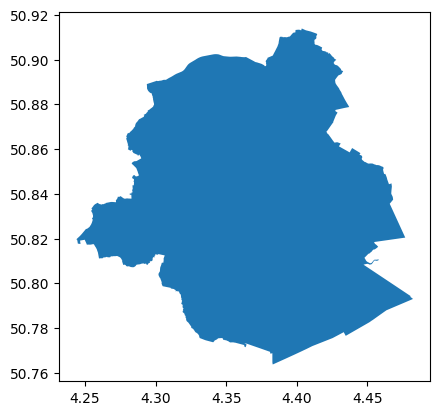

In [11]:
gdf = gpd.read_file('brussels_dissolved.geojson')
gdf.plot()

### Setting up a Dask cluster

In [12]:
cluster = LocalCluster()
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 10.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46277,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35369,Total threads: 1
Dashboard: http://127.0.0.1:45779/status,Memory: 2.50 GiB
Nanny: tcp://127.0.0.1:40265,


### Connection to the EOPF catalog

This is the link to the EOPF catalog from which we will retrieve our data from: 

In [13]:
eopf_catalog = Client.open(url="https://stac.core.eopf.eodc.eu/")

In this tutorial, we will use the Sentinel-2 and Sentinel-3 collections but the eopf catalog consists of more collections:

In [14]:
for collection in eopf_catalog.get_all_collections():
        print(collection.id)

sentinel-2-l2a
sentinel-1-l1-grd
sentinel-3-slstr-l2-lst
sentinel-1-l2-ocn
sentinel-3-slstr-l2-frp
sentinel-3-olci-l2-lfr
sentinel-3-olci-l2-lrr
sentinel-3-olci-l1-efr
sentinel-3-slstr-l1-rbt
sentinel-2-l1c
sentinel-1-l1-slc
sentinel-3-olci-l1-err


## Sentinel 2: True colour composite and Normalised Difference Vegetation Index

To create a map for the Brussels are with the true color composite and the NDVI index, we will have to use the sentinel-2-l2a collection. 

### Parameters

Since lots of images are not yet in the zarr catalog, we start with a rather broad search and define the parameters over a long time period:

In [16]:
period = "2025-01-01/2026-03-08"
aoi = gdf.geometry.iloc[0].__geo_interface__

When using a Geopandas daset, we need to use "__geo_interface__" (please see the [pystac-client documentation](https://pystac-client.readthedocs.io/en/latest/api.html)). 

To search the Sentinel-2 EOPF catalog, you can use the following command using pystac:

In [17]:
items_s2 = eopf_catalog.search(
    collections='sentinel-2-l2a',
    intersects=aoi,
    datetime=period
   ).item_collection()

/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2C_MSIL2A_20251217T104451_N0511_R008_T31UFS_20251217T144413' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2C_MSIL2A_20251217T104451_N0511_R008_T31UES_20251217T144413' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2A_MSIL2A_20251102T105231_N0511_R051_T31UFS_20251102T144301' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2B_MSIL2A_20251102T104109_N0511_R008_T31UES_20251102T112516' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2C_MSIL2A_20251031T105221_N0511_R051_T31UFS_20251031T144221' is deprecated.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The it

We notice a lot of warnings above and these are data are actually deprecated. Below, we will show how to filter these items out. Before this, let's count the number of items from this Sentinel-2 collection:

In [18]:
print(f'There are {len(items_s2)} items in the collection')

There are 223 items in the collection


Show the first 10 items in the collection:

In [19]:
for item in items_s2[0:10]:
    print(item)

<Item id=S2C_MSIL2A_20260307T103911_N0512_R008_T31UFS_20260307T161311>
<Item id=S2C_MSIL2A_20260307T103911_N0512_R008_T31UES_20260307T161311>
<Item id=S2B_MSIL2A_20260305T105029_N0512_R051_T31UFS_20260305T144521>
<Item id=S2B_MSIL2A_20260305T105029_N0512_R051_T31UES_20260305T144521>
<Item id=S2B_MSIL2A_20260302T103849_N0512_R008_T31UFS_20260302T161544>
<Item id=S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544>
<Item id=S2C_MSIL2A_20260228T105001_N0512_R051_T31UFS_20260228T145912>
<Item id=S2C_MSIL2A_20260228T105001_N0512_R051_T31UES_20260228T145912>
<Item id=S2C_MSIL2A_20260225T104021_N0512_R008_T31UFS_20260225T144110>
<Item id=S2C_MSIL2A_20260225T104021_N0512_R008_T31UES_20260225T144110>


To learn a bit about the data, let's have a look at one item:

In [20]:
item_s2 = items_s2[0]
item_s2

<Item id=S2C_MSIL2A_20260307T103911_N0512_R008_T31UFS_20260307T161311>

Expanding this item and especially doing so for the "properties", we can learn many interesting things such as the percentage cloud cover, the Sentinel-2 UTM tile, etc. Before proceeding, it would be good to see what the Sentinel-2 tiles look like with respect to our area of interest in order to narrow our search a bit. 

To do so, we use the Folium Python library. More specifically, we notice that the print output above includes the following two tiles: 31UES and 31UFS. We put the stac search results into a Geopandas dataframe: 

In [21]:
df = gpd.GeoDataFrame.from_features(items_s2.to_dict(), crs="epsg:4326")
df.head()

,geometry,gsd,created,mission,sci:doi,updated,datetime,platform,grid:code,proj:bbox,...,processing:version,product:timeliness,sat:absolute_orbit,sat:relative_orbit,view:sun_elevation,processing:facility,processing:software,eopf:instrument_mode,product:timeliness_category,sat:platform_international_designator
0,"POLYGON ((4.43705 51.38253, 4.46157 51.44192, ...",10.0,2026-03-07T20:23:58.515446Z,Sentinel-2,10.5270/S2_-znk9xsj,2026-03-07T20:23:58.515446Z,2026-03-07T10:39:11.025000Z,sentinel-2c,MGRS-31UFS,"[4.408715109637645, 50.42629366061962, 6.01702...",...,05.12,PT3H,7843,8,57.743626,ESA,{'EOPF-CPM': '2.6.2'},INS-NOBS,NRT,2015-028A
1,"POLYGON ((4.06085 50.45675, 4.11126 50.58199, ...",10.0,2026-03-07T20:10:21.545416Z,Sentinel-2,10.5270/S2_-znk9xsj,2026-03-07T20:10:21.545416Z,2026-03-07T10:39:11.025000Z,sentinel-2c,MGRS-31UES,"[4.060847991024338, 50.453523278919015, 4.5795...",...,05.12,PT3H,7843,8,58.057908,ESA,{'EOPF-CPM': '2.6.2'},INS-NOBS,NRT,2015-028A
2,"POLYGON ((5.96823 50.65046, 5.92752 50.57, 5.8...",10.0,2026-03-05T16:52:48.306021Z,Sentinel-2,10.5270/S2_-znk9xsj,2026-03-05T16:52:48.306021Z,2026-03-05T10:50:29.024000Z,sentinel-2b,MGRS-31UFS,"[4.408715109637645, 50.42811512309479, 6.01702...",...,05.12,PT3H,46981,51,58.060884,ESA,{'EOPF-CPM': '2.6.2'},INS-NOBS,NRT,2015-028A
3,"POLYGON ((2.99971 51.45118, 4.57954 51.44054, ...",10.0,2026-03-05T16:53:15.098032Z,Sentinel-2,10.5270/S2_-znk9xsj,2026-03-05T16:53:15.098032Z,2026-03-05T10:50:29.024000Z,sentinel-2b,MGRS-31UES,"[2.999712175851301, 50.453523278919015, 4.5795...",...,05.12,PT3H,46981,51,58.332325,ESA,{'EOPF-CPM': '2.6.2'},INS-NOBS,NRT,2015-028A
4,"POLYGON ((4.4369 51.3775, 4.44514 51.39754, 4....",10.0,2026-03-02T21:27:51.801395Z,Sentinel-2,10.5270/S2_-znk9xsj,2026-03-02T21:27:51.801395Z,2026-03-02T10:38:49.024000Z,sentinel-2b,MGRS-31UFS,"[4.408715109637645, 50.42629366061962, 6.01702...",...,05.12,PT3H,46938,8,59.690829,ESA,{'EOPF-CPM': '2.6.2'},INS-NOBS,NRT,2015-028A


In order to see the relevant Sentinel-2 tiles, one way is to do a Folium plot:

In [22]:
## Code adapted from:
## https://stacspec.org/en/tutorials/reading-stac-planetary-computer/
## https://courses.spatialthoughts.com/python-dataviz.html#multi-layer-interactive-maps
m = df[["geometry", "datetime", "grid:code", "eo:cloud_cover"]].explore(column = 'grid:code',style_kwds={"fillOpacity": 0.9})
m = gdf.explore(m=m, color = 'red')
m

If you hover over the tiles, we see that the AOI covers two tiles: 31UES and 31UFS. In what follows, we will select only the tile 31UES. Otherwise, we will also have to create a mosaic which is beyond the scope of this tutorial. Next, we create some filters for cloud cover, the Sentinel 2 tile (grid:code) and whether the data have been deprecated or not (and hence no url exists):

In [23]:
filters = {
    "eo:cloud_cover":{"lt":20},
    "deprecated":{'eq': False},
    "grid:code": {'eq': "MGRS-31UES"}
 }

Do a new search:

In [24]:
items_s2_filtered = eopf_catalog.search(
    collections='sentinel-2-l2a',
    intersects=aoi,
    query = filters,
    datetime=period
   ).item_collection()

In [25]:
print(f'There are {len(items_s2_filtered)} items in the S2-collection')

There are 5 items in the S2-collection


In [26]:
for item in items_s2_filtered:
    print(item)

<Item id=S2B_MSIL2A_20260305T105029_N0512_R051_T31UES_20260305T144521>
<Item id=S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544>
<Item id=S2C_MSIL2A_20260225T104021_N0512_R008_T31UES_20260225T144110>
<Item id=S2B_MSIL2A_20260104T105339_N0511_R051_T31UES_20260104T125442>
<Item id=S2B_MSIL2A_20251225T105359_N0511_R051_T31UES_20251225T130829>


Let's select the image with the least cloud cover. According to this tutorial, there should be a quicklook image such that we can have a quick look at the data coverage:

In [27]:
## Code based on:
## https://stacspec.org/en/tutorials/reading-stac-planetary-computer/
item_least_cloud = min(items_s2_filtered, key=lambda item: item.properties["eo:cloud_cover"])
item_least_cloud.id

'S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544'

In [28]:
item_assets_least_cloud = item_least_cloud.get_assets(media_type=MediaType.ZARR)
item_assets_least_cloud

{'SR_10m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/products/cpm_v262/S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544.zarr/measurements/reflectance/r10m>,
 'SR_20m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/products/cpm_v262/S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544.zarr/measurements/reflectance/r20m>,
 'SR_60m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/products/cpm_v262/S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544.zarr/measurements/reflectance/r60m>,
 'AOT_10m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/products/cpm_v262/S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544.zarr/quality/atmosphere/r10m/aot>,
 'B01_20m': <Asset href=https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/p

Based on this [EOPF tutorial](https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/44_eopf_stac_xarray_tutorial.html#prerequisites), we wanted to have a quick look at the image but noticed that there was no option to do so. Moreover, we noticed that we could not create a filter based on the "no data" in pystac as this variable was not available to our knowledge. Instead, we created a quick RGB visualisation based on [this](https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/610_s2_s3_fusion.html) and this [tutorial](https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/61_sardinia_s2_tfci.html). 

In [30]:
## Obtain the url for the least cloudy image
cloud_storage_least_cloud = item_assets_least_cloud['product'].href
print(cloud_storage_least_cloud)

https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/02/products/cpm_v262/S2B_MSIL2A_20260302T103849_N0512_R008_T31UES_20260302T161544.zarr


In [31]:
dt_least_cloud = xr.open_datatree(
    cloud_storage_least_cloud,     
    engine="zarr",
    chunks="auto"      
)

/opt/conda/lib/python3.12/site-packages/xarray_sentinel/esa_safe.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


A great way to understand these data (if you are using this for the first time is to print it). Please uncomment the following line if you want to learn more:

In [33]:
## dt_least_cloud

In order to visualise the RGB image, we need to obtain the Red(R)-Green(G)-Blue(B) bands and need to obtain these bands from the "measurements" group. We choose to use the 20 metres resolution:

In [34]:
least_cloud_meas = dt_least_cloud.measurements.reflectance.r20m
least_cloud_meas

<xarray.DataTree 'r20m'>
Group: /measurements/reflectance/r20m
    Dimensions:  (y: 5490, x: 5490)
    Coordinates:
      * y        (y) float32 22kB 5.7e+06 5.7e+06 5.7e+06 ... 5.59e+06 5.59e+06
      * x        (x) float32 22kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
    Data variables:
        b01      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b02      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b03      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b04      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b05      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b06      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b07      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b11      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b12      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>
        b8a      (y, x) float64 241MB dask.array<chunksize=(3660, 3660), meta=np.ndarray>

In [36]:
## Code adapted from:
## https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/610_s2_s3_fusion.html
rgb_least_cloud = least_cloud_meas.to_dataset()[["b04", "b03", "b02"]].to_array()
## rgb_least_cloud # Please uncomment if you want to see this

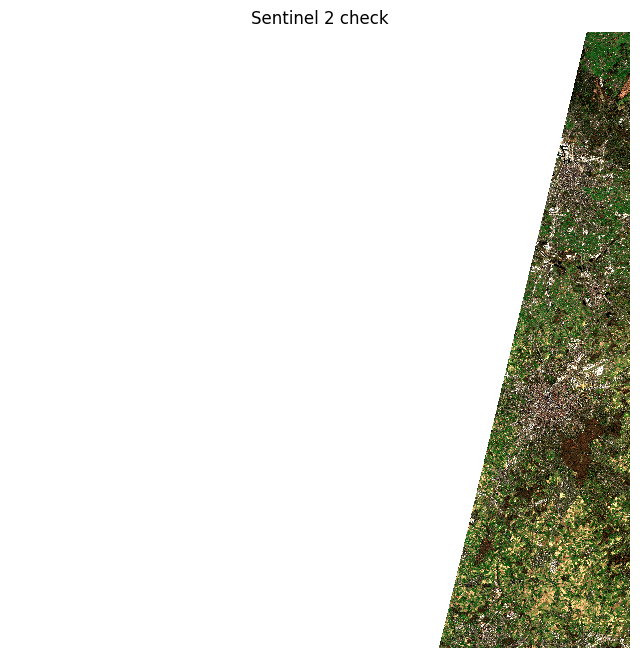

In [37]:
rgb_least_cloud.plot.imshow(figsize=(8, 8), robust=True)
plt.title("Sentinel 2 check")
plt.axis("off")
plt.show()

We think that the AOI falls within this image and with a quick plot using Folium shows this. Alternatively, we can also add the Geopandas dataframe of the Brussels area on top of this image but this would need a reprojection to the UTM CRS projection of the Sentinel-2 tile.

Nevertheless, we will use a more complete image/item. After some trail and error:

## Heading 3

--> *Textual description*

<hr>

## 💪 Now it is your turn

### Task 1: Change your study area
* Go to https://geojson.io/ and draw an Area Of Interest (AOI) and save it as a GeoJSON.
* Move the GeoJSON file to a directory and read it into the script.
* Find out which Sentinel-2 tiles are relevant for your AOI using the visualisation script above. In this tutorial, we do not work with multiple Sentinel-2 tiles yet.
* Alternatively, you can also work with bounding box coordinates and use http://bboxfinder.com/. Rather than using "intersects", you can use "bbox" option instead when you extract the images using the eopf catalog search in pystac. There are multiple examples in the EOPF tutorials that use this approach.

### Task 2: Experiment with the parameters and filters
* Compare data availability across different months for the Sentinel-2 and Sentinel-3 data and change the parameters for the dates.
* Try to find matching dates between the two Sentinel datasets.
* Try to experiment with different seasons (winter, summer). At the time of writing this tutorial, this is currently very much subject to the current data availability.
### Task 3: Try different indices
* You can experiment with different indices such as Modified Normalised Difference Water Index (MNDWI), Normalised Different Building Index (NDBI), etc.
* Compare the maps of these indices with the maps of the LST. What can you observe?

### Task 4: Create a map for the diurnal differences in Land Surface Temperature
* Look at the differences between the Land Surface Temperature (LST) for the ROI between daytime and nighttime LST. As an example, you can follow this [EOPF tutorial of the Normalised Burn ratio](https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/63_sardinia_dNBR.html).

## Conclusion

--> *This section summarises the objectives of the notebook, what a learner learned and what possible conclusions / results were obtained.*

## What's next?

* **Mosaicing:** In the current code, we only used one tile of Sentinel-2. In a follow-up code, we would like to repeat the workflow if the ROI spans two or more Sentinel-2 tiles.
* Create a **median composite** both for the NDVI and LST and clip this to the AOI. This code allows one to work with different files simultaneously across time.
* **Overlay the Sentinel-2 NDVI data with the Sentinel-3 LST** and do some analytics based on the pixel values of both datasets (e.g. correlation, regression). Doing this, one has to (perfectly) align the pixels of both Sentinel datasets.
* We did not **incorporate the use of cloud masks** in this tutorial. We carefully selected an image with very low cloud cover here. However, it possible that the image has more cloud cloud cover. In the next tutorial(s), we hope to incorporate this. 

## References

Roy, B., & Bari, E. (2022). Examining the relationship between land surface temperature and landscape features using spectral indices with Google Earth Engine. Heliyon, 8(9).

https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/44_eopf_stac_xarray_tutorial.html#prerequisites

https://eopf-toolkit.github.io/eopf-101/04_eopf_and_stac/43_eopf_stac_connection.html

https://eopf-toolkit.github.io/eopf-101/06_eopf_zarr_in_action/62_sardinia_s3_lst.html

https://sentiwiki.copernicus.eu/__attachments/1672112/OMPC.ACR.HBK.002%20-%20Sentinel%203%20SLSTR%20Land%20Handbook%202024%20-%201.4.pdf?inst-v=96021aea-734a-44d2-9ca8-2228c7de7290#:~:text=Land%20surface%20temperature%20products,ice%20and%20inland%20water%20pixels.

https://www.geopythontutorials.com/notebooks/dask_median_composite.html from Ujaval Gandhi

https://stacspec.org/en/tutorials/reading-stac-planetary-computer/

https://www.geopythontutorials.com/notebooks/xarray_processing_satellite_images.html

[Mapping and Data Visualization with Python Course](https://spatialthoughts.com/courses/python-dataviz/) by Ujaval Gandhi www.spatialthoughts.com

https://pystac-client.readthedocs.io/en/latest/api.html

https://eopf-sample-service.github.io/eopf-sample-notebooks/sentinel-3-heatwave-mapping/